In [1]:
# Add project root to Python path so we can import from utils module
import sys
from pathlib import Path
project_root = Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import model from centralized utils module
# This avoids code duplication across notebooks and uses consistent model configuration
from utils.models import model

# Alternative: If you want to define the model inline instead of using centralized config, uncomment below:
# from dotenv import load_dotenv
# load_dotenv(dotenv_path="../.env", override=True)
# from langchain.chat_models import init_chat_model
# model = init_chat_model("openai:o3-mini")

# Note: For other providers (Azure, Bedrock, Vertex AI), update utils/models.py 
# See utils/models.py for detailed instructions on switching LLM providers

In [2]:
import sqlite3
import requests
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

def get_engine_for_pl_db():
    """Pull sql file, populate in-memory database, and create engine."""


    connection = sqlite3.connect("pl.db", check_same_thread=False)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )

engine = get_engine_for_pl_db()
pl_db = SQLDatabase(engine)

In [31]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore

# Initializing long term memory store 
in_memory_store = InMemoryStore()

# Initializing checkpoint for thread-level memory 
checkpointer = MemorySaver()

In [3]:
from typing_extensions import TypedDict
from typing import Annotated, List
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.managed.is_last_step import RemainingSteps

class InputState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [4]:
class State(InputState):
    loaded_memory: str
    remaining_steps: int

In [5]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore

# Initializing long term memory store 
in_memory_store = InMemoryStore()

# Initializing checkpoint for thread-level memory 
checkpointer = MemorySaver()

In [6]:
from langchain_core.tools import tool

@tool
def get_team_table_stats(team_name: str, year: str) -> str:
    """Get the stats of a team in the Premier League table for the season specified by year."""
    query = f"""
    SELECT * FROM pl_table_{year} WHERE Team LIKE "%{team_name}%"
    """
    result = pl_db.run(query, include_columns=True)
    return str(result)

@tool
def get_fixtures(team_name: str, year: str) ->str:
    """Get the fixtures of a team in the Premier League for the season specified by year."""
    query = f"""
    SELECT * FROM pl_matches_{year} WHERE HomeTeam LIKE "%{team_name}%" OR AwayTeam LIKE "%{team_name}%"
    """
    result = pl_db.run(query, include_columns=True)
    return str(result)

@tool
def get_teams(year: str) ->str:
    """Get the teams in the Premier League for the season specified by year."""
    query = f"""
    SELECT DISTINCT Team FROM pl_table_{year}
    """
    result = pl_db.run(query, include_columns=True)
    return str(result)

@tool
def custom_sql_query(query: str) -> str:
    """Run a custom SQL query against the Premier League database. Available tables are pl_table_{year} and pl_matches_{year} where year can be 2526 (current season), 2425, 2324 (past seasons). Matches tables contain the fixtures and results, while table tables contain the league standings. Use this tool if the information requested by the customer cannot be retrieved effeciently with the other tools. Remember to only run SELECT queries to prevent data manipulation.
    Columns in matches tables: "Date", "HomeTeam", "AwayTeam", "Full_Time_Home_Team_Goals", "Full_Time_Away_Team_Goals",
"Full_Time_Result", "Half_Time_Home_Team_Goals", "Half_Time_Away_Team_Goals", "Half_Time_Result", "Match_Referee",
"Home_Team_Shots", "Away_Team_Shots", "Home_Team_Shots_on_Target", "Away_Team_Shots_on_Target", "Home_Team_Fouls_Committed", "Away_Team_Fouls_Committed", "Home_Team_Corners", "Away_Team_Corners", "Home_Team_Yellow_Cards", "Away_Team_Yellow_Cards", "Home_Team_Red_Cards", "Away_Team_Red_Cards"
    Columns in table tables: Position,Team,Matches_Played,Points,Goals_For,Goals_Against,Goal_Difference,Shots_On_Target_For,Shots_On_Target_Against,Corners_For,Corners_Against,Red_Cards_For,Red_Cards_Against,Yellow_Cards_For,Yellow_Cards_Against
    Make sure to specify the season in the query by using the correct table name (e.g. pl_matches_2526 for the current season fixtures and results, pl_table_2425 for the past season league standings, etc.)
    """
    # Verify if the query is valid and only allows SELECT statements to prevent data manipulation
    if not query.strip().lower().startswith("select"):
        return "Only SELECT queries are allowed."
    result = pl_db.run(query, include_columns=True)
    return str(result)

pl_tools = [get_team_table_stats, get_fixtures, get_teams, custom_sql_query]


In [7]:
def generate_subagent_prompt(league_name = "Premier League"):
    return f"""
    <important_background>
    You are a subagent among a team of assistants. You are specialized for retrieving and processing {league_name} team statistics information. 
    If you are unable to retrieve the team information, respond that you are unable to retrieve the information.
    IMPORTANT: Your interaction with the customer is done through an automated system. You are not directly interacting with the customer, so avoid chitchat or follow up questions and focus PURELY on responding to the request with the necessary information. 
    </important_background>
     
    <tools>
    You have access to two tools. These tools enable you to retrieve and process team statistics from the database. Here are the tools:
    - get_team_table_stats: This tool retrieves the current season statistics for the team.For the current season 2025-26 use year=2526 when calling the tool. Data for the last 3 seasons is available in the database, so you can also use this tool to retrieve historical data for the team if needed.
    - get_fixtures: This tool retrieves all matches played by a team in the given year, both home and away, sorted chronologically. For the current season 2025-26 use year=2526 when calling the tool. Data for the last 3 seasons is available in the database, so you can also use this tool to retrieve historical data for the team if needed.
    - get_teams: This tool retrieves the list of teams in the {league_name} for the specified year. For the current season 2025-26 use year=2526 when calling the tool. Data for the last 3 seasons is available in the database, so you can also use this tool to retrieve historical data for past years if needed.
    - custom_sql_query: This tool allows you to run a custom SQL query against the {league_name} database. Use this tool if the information requested by the customer cannot be retrieved effeciently with the other tools. Remember to only run SELECT queries to prevent data manipulation.
    </tools>
    
   <core_responsibilities>
    - Retrieve and process team statistics information from the database
    - Provide detailed information about tean, including wins, losses, goals scored, teams that play well against certain teams, etc. when the customer asks for it.
    - If you are unable to retrieve the information, respond that you are unable to retrieve the information.
    - Always try to use the most effecient tool for the query, use the custom_sql_query tool only when you can bypass multiple tool calls to the other tools with a customized sql query.
    - When the customer asks for comparison across seasons, use the tools to retrieve historical data for the team and provide a detailed comparison.
    - Always maintain a pundit-like, analytical, and detailed demeanor in your responses.
    </core_responsibilities>
    
    You may have additional context that you should use to help answer the customer's query. It will be provided to you below:
    """

In [8]:
from rosidl_cli.command.generate.api import generate
from langchain.agents import create_agent

# Define the subagent 
pl_information_subagent = create_agent(
    model=model, 
    tools=pl_tools, 
    name="pl_information_subagent",
    system_prompt=generate_subagent_prompt("English Premier League"), 
    state_schema=State, 
    checkpointer=checkpointer, 
    store=in_memory_store
)

In [9]:
from langchain_core.tools import tool

def get_engine_for_ligue1_db():
    """Pull sql file, populate in-memory database, and create engine."""


    connection = sqlite3.connect("ligue1.db", check_same_thread=False)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )

engine = get_engine_for_ligue1_db()
ligue1_db = SQLDatabase(engine)

@tool
def get_team_table_stats(team_name: str, year: str) -> str:
    """Get the stats of a team in the French Ligue 1 table for the season specified by year."""
    query = f"""
    SELECT * FROM ligue1_table_{year} WHERE Team LIKE "%{team_name}%"
    """
    result = ligue1_db.run(query, include_columns=True)
    return str(result)

@tool
def get_fixtures(team_name: str, year: str) ->str:
    """Get the fixtures of a team in the French Ligue 1 for the season specified by year."""
    query = f"""
    SELECT * FROM ligue1_matches_{year} WHERE HomeTeam LIKE "%{team_name}%" OR AwayTeam LIKE "%{team_name}%"
    """
    result = ligue1_db.run(query, include_columns=True)
    return str(result)

def get_teams(year: str) ->str:
    """Get the teams in the French Ligue 1 for the season specified by year."""
    query = f"""
    SELECT DISTINCT Team FROM ligue1_table_{year}
    """
    result = ligue1_db.run(query, include_columns=True)
    return str(result)

@tool
def custom_sql_query(query: str) -> str:
    """Run a custom SQL query against the French Ligue 1 database. Available tables are ligue1_table_{year} and ligue1_matches_{year} where year can be 2526 (current season), 2425, 2324 (past seasons). Matches tables contain the fixtures and results, while table tables contain the league standings. Use this tool if the information requested by the customer cannot be retrieved effeciently with the other tools. Remember to only run SELECT queries to prevent data manipulation.
    Columns in matches tables: "Date", "HomeTeam", "AwayTeam", "Full_Time_Home_Team_Goals", "Full_Time_Away_Team_Goals",
"Full_Time_Result", "Half_Time_Home_Team_Goals", "Half_Time_Away_Team_Goals", "Half_Time_Result", "Match_Referee",
"Home_Team_Shots", "Away_Team_Shots", "Home_Team_Shots_on_Target", "Away_Team_Shots_on_Target", "Home_Team_Fouls_Committed", "Away_Team_Fouls_Committed", "Home_Team_Corners", "Away_Team_Corners", "Home_Team_Yellow_Cards", "Away_Team_Yellow_Cards", "Home_Team_Red_Cards", "Away_Team_Red_Cards"
    Columns in table tables: Position,Team,Matches_Played,Points,Goals_For,Goals_Against,Goal_Difference,Shots_On_Target_For,Shots_On_Target_Against,Corners_For,Corners_Against,Red_Cards_For,Red_Cards_Against,Yellow_Cards_For,Yellow_Cards_Against
    Make sure to specify the season in the query by using the correct table name (e.g. ligue1_matches_2526 for the current season fixtures and results, ligue1_table_2425 for the past season league standings, etc.)
    """
    # Verify if the query is valid and only allows SELECT statements to prevent data manipulation
    if not query.strip().lower().startswith("select"):
        return "Only SELECT queries are allowed."
    result = ligue1_db.run(query, include_columns=True)
    return str(result)

ligue1_tools = [get_team_table_stats, get_fixtures, get_teams, custom_sql_query]

In [10]:
from langchain.agents import create_agent

# Define the subagent 
ligue1_information_subagent = create_agent(
    model=model, 
    tools=ligue1_tools, 
    name="ligue1_information_subagent",
    system_prompt=generate_subagent_prompt("French Ligue 1"), 
    state_schema=State, 
    checkpointer=checkpointer, 
    store=in_memory_store
)

In [11]:
from langchain_core.tools import tool

def get_engine_for_seria_db():
    """Pull sql file, populate in-memory database, and create engine."""


    connection = sqlite3.connect("seria.db", check_same_thread=False)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )

engine = get_engine_for_seria_db()
seria_db = SQLDatabase(engine)


@tool
def get_team_table_stats(team_name: str, year: str) -> str:
    """Get the stats of a team in the Italian Serie A table for the season specified by year."""
    query = f"""
    SELECT * FROM seria_table_{year} WHERE Team LIKE "%{team_name}%"
    """
    result = seria_db.run(query, include_columns=True)
    return str(result)

@tool
def get_fixtures(team_name: str, year: str) ->str:
    """Get the fixtures of a team in the Italian Serie A for the season specified by year."""
    query = f"""
    SELECT * FROM seria_matches_{year} WHERE HomeTeam LIKE "%{team_name}%" OR AwayTeam LIKE "%{team_name}%"
    """
    result = seria_db.run(query, include_columns=True)
    return str(result)

def get_teams(year: str) ->str:
    """Get the teams in the Italian Serie A for the season specified by year."""
    query = f"""
    SELECT DISTINCT Team FROM seria_table_{year}
    """
    result = seria_db.run(query, include_columns=True)
    return str(result)

@tool
def custom_sql_query(query: str) -> str:
    """Run a custom SQL query against the Italian Serie A database. Available tables are seria_table_{year} and seria_matches_{year} where year can be 2526 (current season), 2425, 2324 (past seasons). Matches tables contain the fixtures and results, while table tables contain the league standings. Use this tool if the information requested by the customer cannot be retrieved effeciently with the other tools. Remember to only run SELECT queries to prevent data manipulation.
    Columns in matches tables: "Date", "HomeTeam", "AwayTeam", "Full_Time_Home_Team_Goals", "Full_Time_Away_Team_Goals",
"Full_Time_Result", "Half_Time_Home_Team_Goals", "Half_Time_Away_Team_Goals", "Half_Time_Result", "Match_Referee",
"Home_Team_Shots", "Away_Team_Shots", "Home_Team_Shots_on_Target", "Away_Team_Shots_on_Target", "Home_Team_Fouls_Committed", "Away_Team_Fouls_Committed", "Home_Team_Corners", "Away_Team_Corners", "Home_Team_Yellow_Cards", "Away_Team_Yellow_Cards", "Home_Team_Red_Cards", "Away_Team_Red_Cards"
    Columns in table tables: Position,Team,Matches_Played,Points,Goals_For,Goals_Against,Goal_Difference,Shots_On_Target_For,Shots_On_Target_Against,Corners_For,Corners_Against,Red_Cards_For,Red_Cards_Against,Yellow_Cards_For,Yellow_Cards_Against
    Make sure to specify the season in the query by using the correct table name (e.g. seria_matches_2526 for the current season fixtures and results, seria_table_2425 for the past season league standings, etc.)
    """
    # Verify if the query is valid and only allows SELECT statements to prevent data manipulation
    if not query.strip().lower().startswith("select"):
        return "Only SELECT queries are allowed."
    result = seria_db.run(query, include_columns=True)
    return str(result)

seria_tools = [get_team_table_stats, get_fixtures, get_teams, custom_sql_query]

In [12]:
from langchain.agents import create_agent

# Define the subagent 
seria_information_subagent = create_agent(
    model=model, 
    tools=seria_tools, 
    name="seria_information_subagent",
    system_prompt=generate_subagent_prompt("Italian Serie A"), 
    state_schema=State, 
    checkpointer=checkpointer, 
    store=in_memory_store
)

In [13]:
from langchain_core.tools import tool

def get_engine_for_bundesliga_db():
    """Pull sql file, populate in-memory database, and create engine."""


    connection = sqlite3.connect("bundesliga.db", check_same_thread=False)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )

engine = get_engine_for_bundesliga_db()
bundesliga_db = SQLDatabase(engine)


@tool
def get_team_table_stats(team_name: str, year: str) -> str:
    """Get the stats of a team in the German Bundesliga table for the season specified by year."""
    query = f"""
    SELECT * FROM bundesliga_table_{year} WHERE Team LIKE "%{team_name}%"
    """
    result = bundesliga_db.run(query, include_columns=True)
    return str(result)

@tool
def get_fixtures(team_name: str, year: str) ->str:
    """Get the fixtures of a team in the German Bundesliga for the season specified by year."""
    query = f"""
    SELECT * FROM bundesliga_matches_{year} WHERE HomeTeam LIKE "%{team_name}%" OR AwayTeam LIKE "%{team_name}%"
    """
    result = bundesliga_db.run(query, include_columns=True)
    return str(result)

def get_teams(year: str) ->str:
    """Get the teams in the German Bundesliga for the season specified by year."""
    query = f"""
    SELECT DISTINCT Team FROM bundesliga_table_{year}
    """
    result = bundesliga_db.run(query, include_columns=True)
    return str(result)

@tool
def custom_sql_query(query: str) -> str:
    """Run a custom SQL query against the German Bundesliga database. Available tables are bundesliga_table_{year} and bundesliga_matches_{year} where year can be 2526 (current season), 2425, 2324 (past seasons). Matches tables contain the fixtures and results, while table tables contain the league standings. Use this tool if the information requested by the customer cannot be retrieved effeciently with the other tools. Remember to only run SELECT queries to prevent data manipulation.
    Columns in matches tables: "Date", "HomeTeam", "AwayTeam", "Full_Time_Home_Team_Goals", "Full_Time_Away_Team_Goals",
"Full_Time_Result", "Half_Time_Home_Team_Goals", "Half_Time_Away_Team_Goals", "Half_Time_Result", "Match_Referee",
"Home_Team_Shots", "Away_Team_Shots", "Home_Team_Shots_on_Target", "Away_Team_Shots_on_Target", "Home_Team_Fouls_Committed", "Away_Team_Fouls_Committed", "Home_Team_Corners", "Away_Team_Corners", "Home_Team_Yellow_Cards", "Away_Team_Yellow_Cards", "Home_Team_Red_Cards", "Away_Team_Red_Cards"
    Columns in table tables: Position,Team,Matches_Played,Points,Goals_For,Goals_Against,Goal_Difference,Shots_On_Target_For,Shots_On_Target_Against,Corners_For,Corners_Against,Red_Cards_For,Red_Cards_Against,Yellow_Cards_For,Yellow_Cards_Against
    Make sure to specify the season in the query by using the correct table name (e.g. bundesliga_matches_2526 for the current season fixtures and results, bundesliga_table_2425 for the past season league standings, etc.)
    """
    # Verify if the query is valid and only allows SELECT statements to prevent data manipulation
    if not query.strip().lower().startswith("select"):
        return "Only SELECT queries are allowed."
    result = bundesliga_db.run(query, include_columns=True)
    return str(result)

bundesliga_tools = [get_team_table_stats, get_fixtures, get_teams, custom_sql_query]

In [14]:

# Define the subagent 
bundesliga_information_subagent = create_agent(
    model=model, 
    tools=bundesliga_tools, 
    name="bundesliga_information_subagent",
    system_prompt=generate_subagent_prompt("German Bundesliga"), 
    state_schema=State, 
    checkpointer=checkpointer, 
    store=in_memory_store
)

In [15]:
def get_engine_for_laliga_db():
    """Pull sql file, populate in-memory database, and create engine."""


    connection = sqlite3.connect("laliga.db", check_same_thread=False)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )

engine = get_engine_for_laliga_db()
laliga_db = SQLDatabase(engine)

@tool
def get_team_table_stats(team_name: str, year: str) -> str:
    """Get the stats of a team in the Spanish LaLiga table for the season specified by year."""
    query = f"""
    SELECT * FROM laliga_table_{year} WHERE Team LIKE "%{team_name}%"
    """
    result = laliga_db.run(query, include_columns=True)
    return str(result)

@tool
def get_fixtures(team_name: str, year: str) ->str:
    """Get the fixtures of a team in the Spanish LaLiga for the season specified by year."""
    query = f"""
    SELECT * FROM laliga_matches_{year} WHERE HomeTeam LIKE "%{team_name}%" OR AwayTeam LIKE "%{team_name}%"
    """
    result = laliga_db.run(query, include_columns=True)
    return str(result)

def get_teams(year: str) ->str:
    """Get the teams in the Spanish La Liga for the season specified by year."""
    query = f"""
    SELECT DISTINCT Team FROM laliga_table_{year}
    """
    result = laliga_db.run(query, include_columns=True)
    return str(result)

@tool
def custom_sql_query(query: str) -> str:
    """Run a custom SQL query against the Spanish La Liga database. Available tables are laliga_table_{year} and laliga_matches_{year} where year can be 2526 (current season), 2425, 2324 (past seasons). Matches tables contain the fixtures and results, while table tables contain the league standings. Use this tool if the information requested by the customer cannot be retrieved effeciently with the other tools. Remember to only run SELECT queries to prevent data manipulation.
    Columns in matches tables: "Date", "HomeTeam", "AwayTeam", "Full_Time_Home_Team_Goals", "Full_Time_Away_Team_Goals",
"Full_Time_Result", "Half_Time_Home_Team_Goals", "Half_Time_Away_Team_Goals", "Half_Time_Result", "Match_Referee",
"Home_Team_Shots", "Away_Team_Shots", "Home_Team_Shots_on_Target", "Away_Team_Shots_on_Target", "Home_Team_Fouls_Committed", "Away_Team_Fouls_Committed", "Home_Team_Corners", "Away_Team_Corners", "Home_Team_Yellow_Cards", "Away_Team_Yellow_Cards", "Home_Team_Red_Cards", "Away_Team_Red_Cards"
    Columns in table tables: Position,Team,Matches_Played,Points,Goals_For,Goals_Against,Goal_Difference,Shots_On_Target_For,Shots_On_Target_Against,Corners_For,Corners_Against,Red_Cards_For,Red_Cards_Against,Yellow_Cards_For,Yellow_Cards_Against
    Make sure to specify the season in the query by using the correct table name (e.g. laliga_matches_2526 for the current season fixtures and results, laliga_table_2425 for the past season league standings, etc.)
    """
    # Verify if the query is valid and only allows SELECT statements to prevent data manipulation
    if not query.strip().lower().startswith("select"):
        return "Only SELECT queries are allowed."
    result = laliga_db.run(query, include_columns=True)
    return str(result)

laliga_tools = [get_team_table_stats, get_fixtures, get_teams, custom_sql_query]

In [16]:
# Define the subagent 
laliga_information_subagent = create_agent(
    model=model, 
    tools=laliga_tools, 
    name="laliga_information_subagent",
    system_prompt=generate_subagent_prompt("Spanish La Liga"), 
    state_schema=State, 
    checkpointer=checkpointer, 
    store=in_memory_store
)

In [17]:
# from langsmith import uuid7
# from langchain_core.messages import HumanMessage

# # Test all the subagents with a sample question about the team with the most yellow cards this season and their position in the league table. This question will require the subagent to use both tools to retrieve the necessary information to answer the question.
# question = "Which team has the most yellow cards in a single match this season across all the top 5 leagues, and which position is that team in the league table now?"

# for agent in [pl_information_subagent, ligue1_information_subagent, seria_information_subagent, bundesliga_information_subagent, laliga_information_subagent]:
#     print(f"\n\n Testing {agent.name}...")
#     config = {"configurable": {"thread_id": uuid7()}}
#     result = agent.invoke({"messages": [HumanMessage(content=question)]}, config=config)
#     for message in result["messages"]:
#         message.pretty_print()

In [29]:

main_agent_prompt = f"""<important_background>
You are the coordinator agent with access to a group of subagents. You are specialized for summarizing information and querying the league-specific subagemts.
If you are unable to retrieve the team information from the subagents, respond that you are unable to retrieve the information.
The current season is 2025-26, but you can also retrieve historical data for the last 3 seasons from the subagents if needed.
IMPORTANT: You are directly interacting with the customer, so maintain a conversational and engaging demeanor while also providing detailed and analytical responses to the customer's queries. You can ask follow up questions to clarify the customer's request if needed, but make sure to keep the conversation focused on providing the necessary information to answer the customer's query.
</important_background>
    
<tools>
You have access to one tool that acts as an interface to all the subagents, each subagent is an expert in retrieving and processing team statistics information for a specific league (Premier League, French Ligue 1, Italian Serie A, German Bundesliga, Spanish La Liga). When you receive a request from the customer, you can decide which subagent to delegate the task to based on the league the question is about. 
- subagent_interface: This tool allows you to delegate the task of retrieving and processing team statistics information to the appropriate subagent based on the league the question is about.
</tools>

<core_responsibilities>
- Provide detailed information about team, including wins, losses, goals scored, teams that play well against certain teams, etc. when the customer asks for it.
- If you are unable to retrieve the information, respond that you are unable to retrieve the information.
- When the customer asks for comparison across seasons, use the tools to retrieve historical data for the team and provide a detailed comparison.
- When a customer query involves multiple leagues, delegate to the appropriate subagent for each league and then synthesize the information retrieved from each subagent to provide a comprehensive answer to the customer.
- For multi-step queries that require multiple interactions with the subagents, break down the task into simpler tasks to ensure faster retrieval of information and better organization of the response.
- Always maintain a pundit-like, analytical, and detailed demeanor in your responses.
</core_responsibilities>

You may have additional context that you should use to help answer the customer's query. It will be provided to you below:
"""

In [30]:
SUBAGENTS = {"english_premier_league_expert": pl_information_subagent, 
             "french_ligue_1_expert": ligue1_information_subagent, 
             "italian_serie_a_expert": seria_information_subagent, 
             "german_bundesliga_expert": bundesliga_information_subagent, 
             "spanish_la_liga_expert": laliga_information_subagent}

@tool
def subagent_interface(
    agent_name: str,
    description: str
) -> str:
    """Launch an ephemeral subagent for a football league specific task.

    Available agents:
    - english_premier_league_expert: Specialized in retrieving and processing English Premier League team statistics information for the past three seasons (25-26, 24-25, 23-24).
    - french_ligue_1_expert: Specialized in retrieving and processing French Ligue 1 team statistics information.
    - italian_serie_a_expert: Specialized in retrieving and processing Italian Serie A team statistics information.
    - german_bundesliga_expert: Specialized in retrieving and processing German Bundesliga team statistics information.
    - spanish_la_liga_expert: Specialized in retrieving and processing Spanish La Liga team statistics information.
    """
    agent = SUBAGENTS[agent_name]
    result = agent.invoke({
        "messages": [
            {"role": "user", "content": description}
        ]
    })
    return result["messages"][-1].content

# Main coordinator agent
main_agent = create_agent(
    model=model,
    tools=[subagent_interface],
    system_prompt=main_agent_prompt,
)

In [34]:
from langsmith import uuid7
from langchain_core.messages import HumanMessage

question = "How did the newly promoted teams in each of the top 5 European leagues perform in the current season? You will have to first identify the promoted teams in each league by finding the teams that were not in the league in the 24-25 season but are in the league in the 25-26 season, and then retrieve their current season performance including their position in the league table, points, goals scored, goals conceded, etc."
config = {"configurable": {"thread_id": uuid7()}}
result = main_agent.invoke({"messages": [HumanMessage(content=question)]}, config=config)
for message in result["messages"]:
    message.pretty_print()

KeyError: 'german_bundesliga_expert,description:'

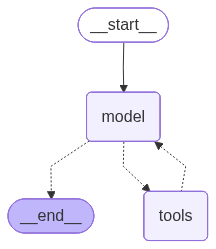

In [33]:
main_agent